## Dataset Link:- [Kaggle](https://www.kaggle.com/competitions/msk-redefining-cancer-treatment/data)

## Unzip data

In [1]:
import zipfile
from pathlib import Path

data_dir = Path('../data')

zip_files = [
    data_dir / 'training_variants.zip',
    data_dir / 'training_text.zip',
    data_dir / 'test_variants.zip',
    data_dir / 'test_text.zip'
]

# 1 & 2. Extract zip files
for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)

## Load data

In [2]:
import pandas as pd
train_data_text = pd.read_csv(data_dir / 'training_text', sep=r'\|\|', engine='python', names=["ID", "TEXT"], skiprows=1)
train_data_variant = pd.read_csv(data_dir / 'training_variants.zip')
test_data_text = pd.read_csv(data_dir / 'test_text', sep=r'\|\|', engine='python', names=["ID", "TEXT"], skiprows=1)
test_data_variant = pd.read_csv(data_dir / 'test_variants.zip')

## Understand data

In [3]:
print(train_data_text)

        ID                                               TEXT
0        0  Cyclin-dependent kinases (CDKs) regulate a var...
1        1   Abstract Background  Non-small cell lung canc...
2        2   Abstract Background  Non-small cell lung canc...
3        3  Recent evidence has demonstrated that acquired...
4        4  Oncogenic mutations in the monomeric Casitas B...
...    ...                                                ...
3316  3316  Introduction  Myelodysplastic syndromes (MDS) ...
3317  3317  Introduction  Myelodysplastic syndromes (MDS) ...
3318  3318  The Runt-related transcription factor 1 gene (...
3319  3319  The RUNX1/AML1 gene is the most frequent targe...
3320  3320  The most frequent mutations associated with le...

[3321 rows x 2 columns]


In [4]:
print(train_data_variant)

        ID    Gene             Variation  Class
0        0  FAM58A  Truncating Mutations      1
1        1     CBL                 W802*      2
2        2     CBL                 Q249E      2
3        3     CBL                 N454D      3
4        4     CBL                 L399V      4
...    ...     ...                   ...    ...
3316  3316   RUNX1                 D171N      4
3317  3317   RUNX1                 A122*      1
3318  3318   RUNX1               Fusions      1
3319  3319   RUNX1                  R80C      4
3320  3320   RUNX1                  K83E      4

[3321 rows x 4 columns]


### Dataset Explanation

**training_variants & test_vaiants**
- Contains structured information about each genetic mutation.
- Columns:
  - `ID`: Unique identifier for each mutation.
  - `Gene`: Name of the gene where the mutation is found.
  - `Variation`: The specific change (mutation) in the gene.
  - `Class`: The effect category of the mutation (an integer from 1 to 9, which is the target to predict).

**training_text & test_text**
- Contains unstructured text data for each mutation.
- Columns:
  - `ID`: Matches the ID in `training_variants` & `test_variants` respectively.
  - `Text`: A detailed description (from medical literature) about the mutation, its context, and possible effects.

For each mutation (ID), you have both structured (gene, variation) and unstructured (text) information. The goal is to use all this information to predict the correct class (effect) of the mutation.

In [5]:
print(train_data_text.head())

   ID                                               TEXT
0   0  Cyclin-dependent kinases (CDKs) regulate a var...
1   1   Abstract Background  Non-small cell lung canc...
2   2   Abstract Background  Non-small cell lung canc...
3   3  Recent evidence has demonstrated that acquired...
4   4  Oncogenic mutations in the monomeric Casitas B...


In [6]:
print(train_data_variant.head())

   ID    Gene             Variation  Class
0   0  FAM58A  Truncating Mutations      1
1   1     CBL                 W802*      2
2   2     CBL                 Q249E      2
3   3     CBL                 N454D      3
4   4     CBL                 L399V      4


In [7]:
train_data_text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3321 entries, 0 to 3320
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      3321 non-null   int64 
 1   TEXT    3316 non-null   object
dtypes: int64(1), object(1)
memory usage: 52.0+ KB


In [8]:
train_data_variant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3321 entries, 0 to 3320
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         3321 non-null   int64 
 1   Gene       3321 non-null   object
 2   Variation  3321 non-null   object
 3   Class      3321 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 103.9+ KB


In [9]:
train_data_text.describe()

,ID
count,3321.000000
mean,1660.000000
std,958.834449
min,0.000000
25%,830.000000
50%,1660.000000
75%,2490.000000
max,3320.000000


In [10]:
train_data_variant.describe()

,ID,Class
count,3321.000000,3321.000000
mean,1660.000000,4.365854
std,958.834449,2.309781
min,0.000000,1.000000
25%,830.000000,2.000000
50%,1660.000000,4.000000
75%,2490.000000,7.000000
max,3320.000000,9.000000


In [11]:
train_data_text.describe()

,ID
count,3321.000000
mean,1660.000000
std,958.834449
min,0.000000
25%,830.000000
50%,1660.000000
75%,2490.000000
max,3320.000000


In [12]:
train_data_text.shape

(3321, 2)

In [13]:
train_data_variant.shape

(3321, 4)

In [14]:
train_data_text.value_counts()

ID    TEXT                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [15]:
train_data_variant.columns.tolist()

['ID', 'Gene', 'Variation', 'Class']

In [16]:
train_data_variant['Class'].value_counts()

Class
7    953
4    686
1    568
2    452
6    275
5    242
3     89
9     37
8     19
Name: count, dtype: int64

In [17]:
train_data_variant_merged = train_data_variant.merge(train_data_text, on = 'ID', how = 'left')

In [18]:
print(train_data_variant_merged)

        ID    Gene             Variation  Class  \
0        0  FAM58A  Truncating Mutations      1   
1        1     CBL                 W802*      2   
2        2     CBL                 Q249E      2   
3        3     CBL                 N454D      3   
4        4     CBL                 L399V      4   
...    ...     ...                   ...    ...   
3316  3316   RUNX1                 D171N      4   
3317  3317   RUNX1                 A122*      1   
3318  3318   RUNX1               Fusions      1   
3319  3319   RUNX1                  R80C      4   
3320  3320   RUNX1                  K83E      4   

                                                   TEXT  
0     Cyclin-dependent kinases (CDKs) regulate a var...  
1      Abstract Background  Non-small cell lung canc...  
2      Abstract Background  Non-small cell lung canc...  
3     Recent evidence has demonstrated that acquired...  
4     Oncogenic mutations in the monomeric Casitas B...  
...                                    

In [19]:
# Find the maximum class count
max_count = train_data_variant_merged['Class'].value_counts().max()
max_count

np.int64(953)

## Oversample each class

In [20]:
from sklearn.utils import resample

balanced_list = []
for c in train_data_variant_merged['Class'].unique():
    class_subset = train_data_variant_merged[train_data_variant_merged['Class'] == c]
    class_oversampled = resample(class_subset, replace=True, n_samples=max_count, random_state=42)
    balanced_list.append(class_oversampled)

train_data_variant_balanced = pd.concat(balanced_list)

train_data_variant_balanced

,ID,Gene,Variation,Class,TEXT
468,468,TP53,K291Q,1,Tumor suppressor p53-dependent apoptosis is th...
2403,2403,NF1,Truncating Mutations,1,Ras (p21'as) interacts directly with the catal...
1160,1160,FAT1,P4309A,1,Chromosome 4q35 is frequently lost in numerous...
472,472,TP53,A347T,1,The tumor suppressor protein p53 is a transcri...
411,411,TP53,S241F,1,The p53 gene is the most commonly mutated targ...
...,...,...,...,...,...
1082,1082,EZH2,Y646F,9,"EZH2, the catalytic subunit of the PRC2 comple..."
1373,1373,AKT2,G161V,9,The serine–threonine kinase AKT regulates prol...
1769,1769,IDH2,R172K,9,The somatic mutations in cytosolic isocitrate ...
1373,1373,AKT2,G161V,9,The serine–threonine kinase AKT regulates prol...


## Shuffle the balanced data

In [21]:
train_data_variant_balanced = train_data_variant_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

train_data_variant_balanced

,ID,Gene,Variation,Class,TEXT
0,1090,KLF4,K409Q,2,Abstract Meningiomas are among the most freque...
1,1555,ALK,R1060H,3,"In the era of personalized medicine, understan..."
2,2205,PTEN,C136R,4,Germline mutations in PTEN have been described...
3,2751,BRAF,N486_P490del,2,We have identifi ed previously undiscovered BR...
4,3293,RET,V804G,1,RET is a transmembrane tyrosine kinase partici...
...,...,...,...,...,...
8572,284,NKX2-1,A339V,7,The genetic factors that determine the risk of...
8573,2833,BRCA2,N517S,6,Twenty percent of individuals with a strong fa...
8574,2435,BRCA1,D1546N,6,Germ line inactivating mutations in BRCA1 conf...
8575,74,RAD50,Deletion,1,"Mre11, Rad50, and Nbs1 function in a protein c..."


## Split back into variants and text files

In [22]:
training_variants_balanced = train_data_variant_balanced[['ID', 'Gene', 'Variation', 'Class']]
training_text_balanced = train_data_variant_balanced[['ID', 'TEXT']]

In [23]:
training_text_balanced

,ID,TEXT
0,1090,Abstract Meningiomas are among the most freque...
1,1555,"In the era of personalized medicine, understan..."
2,2205,Germline mutations in PTEN have been described...
3,2751,We have identifi ed previously undiscovered BR...
4,3293,RET is a transmembrane tyrosine kinase partici...
...,...,...
8572,284,The genetic factors that determine the risk of...
8573,2833,Twenty percent of individuals with a strong fa...
8574,2435,Germ line inactivating mutations in BRCA1 conf...
8575,74,"Mre11, Rad50, and Nbs1 function in a protein c..."


In [24]:
training_variants_balanced

,ID,Gene,Variation,Class
0,1090,KLF4,K409Q,2
1,1555,ALK,R1060H,3
2,2205,PTEN,C136R,4
3,2751,BRAF,N486_P490del,2
4,3293,RET,V804G,1
...,...,...,...,...
8572,284,NKX2-1,A339V,7
8573,2833,BRCA2,N517S,6
8574,2435,BRCA1,D1546N,6
8575,74,RAD50,Deletion,1


## Save to new files

In [25]:
training_text_balanced.to_csv('training_text_balanced.csv', index=False, sep='\t', header=True)
training_variants_balanced.to_csv('training_variants_balanced.csv', index=False)

In [26]:
training_text_balanced_csv = pd.read_csv('training_text_balanced.csv',sep='\t')
training_text_balanced_csv['TEXT'].value_counts()

TEXT
Mutations in BRCA1 and BRCA2 account for the majority of hereditary breast and ovarian cancers, and therefore sequence analysis of both genes is routinely conducted in patients with early-onset breast cancer. Besides mutations that clearly abolish protein function or are known to increase cancer risk, a large number of sequence variants of uncertain signifi cance (VUS) have been identifi ed. Although several functional assays for BRCA1 VUSs have been described, thus far it has not been possible to conduct a high-throughput analysis in the context of the full-length protein. We have developed a relatively fast and easy cDNA-based functional assay to classify BRCA1 VUSs based on their ability to functionally complement BRCA1-defi cient mouse embryonic stem cells. Using this assay, we have analyzed 74 unclassifi ed BRCA1 missense mutants for which all predicted pathogenic variants are confi ned to the BRCA1 RING and BRCT domains.  SIGNIFICANCE: BRCA1 VUSs are frequently found in pati

In [27]:
training_variants_balanced_csv = pd.read_csv('training_variants_balanced.csv')
training_variants_balanced_csv['Class'].value_counts()

Class
2    953
3    953
4    953
1    953
8    953
5    953
6    953
7    953
9    953
Name: count, dtype: int64

## Top 5 most common mutation types

In [28]:
top_variations = train_data_variant['Variation'].value_counts().head(5)
print("Top 5 mutation types:\n", top_variations)

Top 5 mutation types:
 Variation
Truncating Mutations    93
Deletion                74
Amplification           71
Fusions                 34
Overexpression           6
Name: count, dtype: int64


## Top 5 most common genes

In [29]:
top_genes = train_data_variant['Gene'].value_counts().head(5)
print("Top 5 genes:\n", top_genes)

Top 5 genes:
 Gene
BRCA1    264
TP53     163
EGFR     141
PTEN     126
BRCA2    125
Name: count, dtype: int64


## Insights from Top Genes and Mutation Types

### Top 10 genes

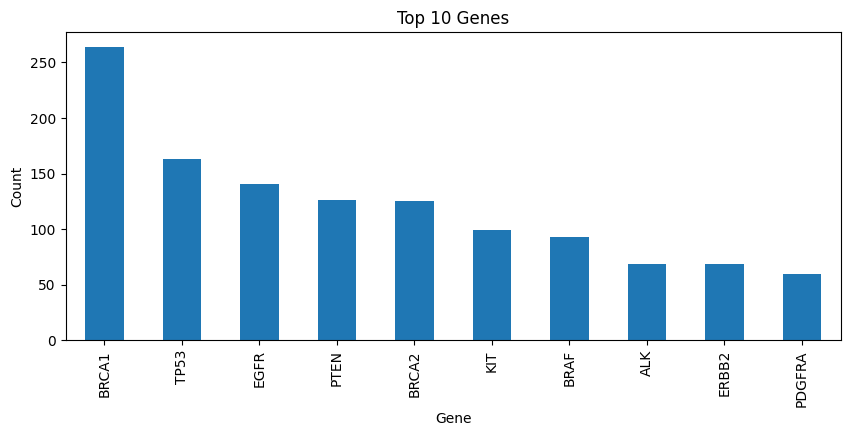

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
train_data_variant['Gene'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Gene')
plt.ylabel('Count')
plt.title('Top 10 Genes')
plt.show()

### Top 10 variations

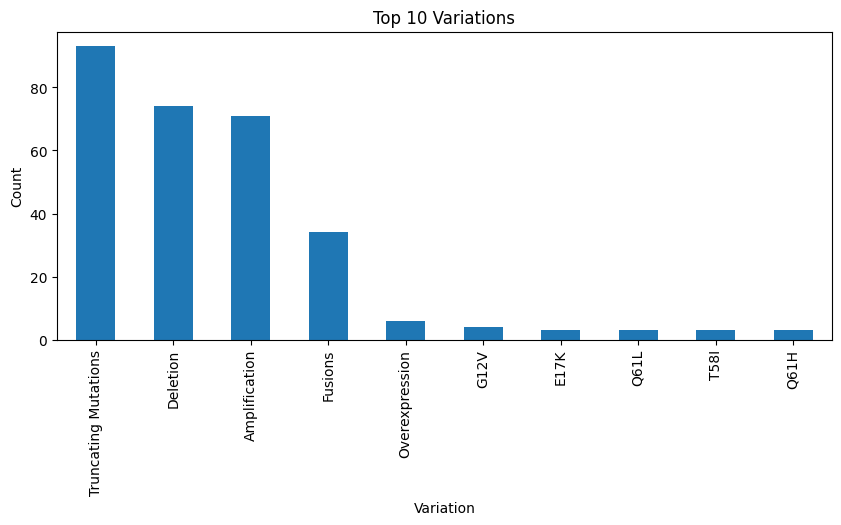

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
train_data_variant['Variation'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Variation')
plt.ylabel('Count')
plt.title('Top 10 Variations')
plt.show()

### Distribution of Text Lengths

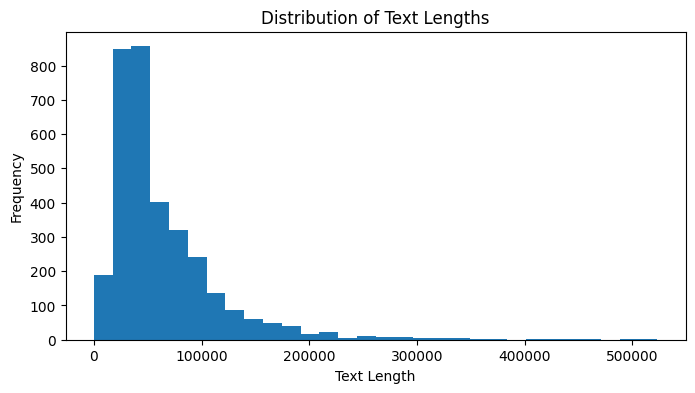

In [32]:
plt.figure(figsize=(8,4))
train_data_text['Text_Length'] = train_data_text['TEXT'].fillna('').apply(len)
plt.hist(train_data_text['Text_Length'], bins=30)
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.title('Distribution of Text Lengths')
plt.show()